## Introduction

 The primary aim of this project is to investigate whether human activity or other human phenomenon, such as climate change, have affected the severity and frequency of wildfires across Oregon. With this in mind, we have two datasets prepared, one directly from the Oregon Fire Department, that has tracked fires from the last 20 years, and one from Kaggle, which utilizes independent survey data from the last 30 or so. 

We will be looking to find ways to measure the time it took fires to be put out, the severity of the fires, as well as the frequency and causes of the fires in our data. This will help us answer our main research question: Are humans contributing to more fires in Oregon?

## Modules

Before we explore, here are the modules being used for this project, and why and how they will contribute to it.

`numpy` : Allows for arithmetic operations in cleaning and organizing our data.
    
`re`: Allows for more precise data cleaning, particularly on dates.
    
`matplotlib.pyplot`: Very good for visualizations.
    
`seaborn`: Our main plotting module, used for our faceted plot, among other things.
    
`plotly.express`: Allows the creation of very cool interactive plots.

`pandas`: This module allows us to create our datasets from csv files.

`os`: To ensure the kernel knows the data is in the folder, as it has been an issue in the past.

`warnings`: Shows any errors potentially occurring in cells.

In [1]:
import seaborn as sns   # to help us plot 
import numpy as np    # to assisst in sorting
import re    # to assist in sorting by specific language
import matplotlib.pyplot as plt  # to assist in plotting and comparison in specific ways
import pandas as pd   # to display the data imported through csv files
import os     # to ensure the data is seen in the folder and able to be ported
import warnings   # to show any potential errors in the code
import plotly.express as px #interactive plotting

And before anything else, we need the kernel to know the data we are using exists in the folder with our project.

In [2]:
os.getcwd()

'/home/jovyan/data271_sp26/lab/lab08/final project folder'

In [3]:
os.listdir()

['finalProj.ipynb',
 '.ipynb_checkpoints',
 'ODF_Fire_Occurrence_Data_2000-2022.csv',
 'Kaggle_Fires_Oregon.csv.xZaQQK',
 'Oregon_Kaggle_Fires.csv']

### Primary Dataset — *[ODF Fire Occurrence Data 2000-2022]*

**Source:** [Oregon Fire Department's survey of fires from 2000 to 2022.](https://data.oregon.gov/Natural-Resources/ODF-Fire-Occurrence-Data-2000-2022/fbwv-q84y/related_content) 

**Original purpose: A collection of fires in the past two decades and noting their specific and broader causes. Design for government and public access, And also gives some more specific information related to districts and restrictions, beyond measuring the severity, cause, and times of the fires.**  
**When collected: January 19, 2023**  
**# of variables in original: 38**  
**Peculiarities: Although not particularly peculiar, one of its data points is a set of coordinates.**

In [4]:
final_df = pd.read_csv("ODF_Fire_Occurrence_Data_2000-2022.csv")
final_df.head()

,Serial,FireCategory,FireYear,Area,DistrictName,UnitName,FullFireNumber,FireName,Size_class,EstTotalAcres,...,Industrial_Restriction,Ign_DateTime,ReportDateTime,Discover_DateTime,Control_DateTime,CreationDate,ModifiedDate,DistrictCode,UnitCode,DistFireNumber
0,108204,STAT,2017,EOA,Klamath-Lake,Lakeview,17-982068-18,Castle 483,A,NaN,...,NaN,NaN,08/08/2017 12:53:00 PM,NaN,NaN,08/08/2017 12:00:00 AM,08/08/2017 02:11:00 PM,98,982,068
1,68272,STAT,2003,NOA,North Cascade,Santiam,03-582216-04,Marion Forks Move Up,A,0.0,...,Unspecified,NaN,09/02/2003 12:00:00 AM,NaN,NaN,09/03/2003 01:43:00 PM,08/23/2011 04:20:00 PM,58,582,216
2,75461,STAT,2006,EOA,Klamath-Lake,Klamath,06-981055-07,BUCK,A,0.1,...,Lvl 4 Complete Shutdown,08/05/2006 03:00:00 PM,08/05/2006 03:45:00 PM,08/05/2006 03:42:00 PM,08/05/2006 06:00:00 PM,08/08/2006 07:43:00 PM,09/16/2006 04:31:00 PM,98,981,055
3,98874,STAT,2014,NOA,Forest Grove,Columbia City,14-532076-15,Hafferman Rd. #1,A,0.1,...,Lvl 2 Limited Shutdown,NaN,09/04/2014 02:20:00 PM,NaN,09/04/2014 02:40:00 PM,09/04/2014 12:00:00 AM,09/05/2014 11:28:00 AM,53,532,076
4,112552,STAT,2017,NOA,North Cascade,Santiam,17-582069-18,Lyons Preposition,A,NaN,...,NaN,NaN,09/12/2017 08:00:00 AM,NaN,NaN,08/29/2018 12:00:00 AM,08/29/2018 12:44:00 PM,58,582,069


In [41]:
final_df.info()
final_df.describe()
final_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Serial                  23490 non-null  int64  
 1   FireCategory            23490 non-null  object 
 2   FireYear                23490 non-null  int64  
 3   Area                    23490 non-null  object 
 4   DistrictName            23490 non-null  object 
 5   UnitName                23490 non-null  object 
 6   FullFireNumber          23490 non-null  object 
 7   FireName                23490 non-null  object 
 8   Size_class              23490 non-null  object 
 9   EstTotalAcres           23411 non-null  float64
 10  Protected_Acres         23490 non-null  float64
 11  HumanOrLightning        23490 non-null  object 
 12  CauseBy                 23362 non-null  object 
 13  GeneralCause            23490 non-null  object 
 14  SpecificCause           23266 non-null

(23490, 38)

### Secondary Dataset — *[1.88 Million Wildfires]*

**Source:** [1.88 Million Wildfires.](https://www.kaggle.com/datasets/rtatman/188-million-us-wildfires?resource=download)  

**Original purpose: To collect and represent data on the total acres burned by wildfires across the United States from 1992 to 2015. This version of that data only takes values that come from Oregon, to match our primary dataset.**  
**When collected: 2017**  
**# of variables in original:39**  
**Peculiarities: Some of the data has multiple datatypes.**

In [8]:
final_df_2 = pd.read_csv("Oregon_Kaggle_Fires.csv", low_memory =False)
final_df_2 = final_df_2[final_df_2['STATE'] == 'OR']
final_df_2.head()

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape
31,32,32,FS-1418907,FED,FS-FIRESTAT,FS,USORDEF,Deschutes National Forest,0601,Deschutes National Forest,...,A,43.995556,-121.414167,13.0,STATE OR PRIVATE,OR,17.0,17.0,Deschutes,AAGtEAAAkK/rtIFaXsCQxlVdbv9FQJCv67SBWl7AkMZVXW...
35,36,36,FS-1418916,FED,FS-FIRESTAT,FS,USORDEF,Deschutes National Forest,0601,Deschutes National Forest,...,A,44.043333,-121.386111,5.0,USFS,OR,17.0,17.0,Deschutes,AAGtEAAAnIRfC7ZYXsCollHyiwVGQJyEXwu2WF7AqJZR8o...
43,44,44,FS-1418924,FED,FS-FIRESTAT,FS,USORDEF,Deschutes National Forest,0601,Deschutes National Forest,...,A,43.955556,-121.352222,5.0,USFS,OR,17.0,17.0,Deschutes,AAGtEAAAxPQQz4pWXsAI2wOlT/pFQMT0EM+KVl7ACNsDpU...
46,47,47,FS-1418935,FED,FS-FIRESTAT,FS,USORUMF,Umatilla National Forest,0614,Umatilla National Forest,...,B,44.911111,-119.696111,5.0,USFS,OR,69.0,69.0,Wheeler,AAGtEAAAQPWcFY3sXcB4PPJJn3RGQED1nBWN7F3AeDzySZ...
48,49,49,FS-1418943,FED,FS-FIRESTAT,FS,USORDEF,Deschutes National Forest,0601,Deschutes National Forest,...,A,43.725278,-121.574167,5.0,USFS,OR,17.0,17.0,Deschutes,AAGtEAAAmIaPJb9kXsDQzvzm1dxFQJiGjyW/ZF7A0M785t...


In [9]:
final_df_2.info()
final_df_2.describe()
final_df_2.shape

<class 'pandas.core.frame.DataFrame'>
Index: 20841 entries, 31 to 171637
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   OBJECTID                    20841 non-null  int64  
 1   FOD_ID                      20841 non-null  int64  
 2   FPA_ID                      20841 non-null  object 
 3   SOURCE_SYSTEM_TYPE          20841 non-null  object 
 4   SOURCE_SYSTEM               20841 non-null  object 
 5   NWCG_REPORTING_AGENCY       20841 non-null  object 
 6   NWCG_REPORTING_UNIT_ID      20841 non-null  object 
 7   NWCG_REPORTING_UNIT_NAME    20841 non-null  object 
 8   SOURCE_REPORTING_UNIT       20841 non-null  object 
 9   SOURCE_REPORTING_UNIT_NAME  20841 non-null  object 
 10  LOCAL_FIRE_REPORT_ID        20841 non-null  int64  
 11  LOCAL_INCIDENT_ID           5030 non-null   object 
 12  FIRE_CODE                   11407 non-null  object 
 13  FIRE_NAME                   16729 

(20841, 39)

When loading data from Kaggle, we had to specify low_memory as False due to multiple dtypes in certain columns, such as 38 and 11. Some columns have far fewer entries than the rest of the dataset, though this does not seem to be specifically tied to the columns with multiple dtypes. Important variables for this project are FIRE_SIZE, FIRE_SIZE_CLASS, FIRE_NAME, STAT_CAUSE_DESCR, and CONT_DATE. 

<a id="cleaning"></a>
---
# Data Cleaning 


Started by checking for duplicates, and found that neither dataset had any.

In [46]:
duplicates1 = final_df[final_df.duplicated(keep=False)]
duplicates1

,Serial,FireCategory,FireYear,Area,DistrictName,UnitName,FullFireNumber,FireName,Size_class,EstTotalAcres,...,Industrial_Restriction,Ign_DateTime,ReportDateTime,Discover_DateTime,Control_DateTime,CreationDate,ModifiedDate,DistrictCode,UnitCode,DistFireNumber


In [11]:
duplicates2 = final_df_2[final_df_2.duplicated(keep=False)]
duplicates2

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape


Another part of the cleaning process was looking for missing values, and assessing whether to get rid of columns with missing values, or to keep them, but fill the columns with NaN or Missing strings.

In [12]:
# Assess missing values in each dataset
missing_vals_1 = final_df.isna().sum()
missing_vals_1

Serial                        0
FireCategory                  0
FireYear                      0
Area                          0
DistrictName                  0
UnitName                      0
FullFireNumber                0
FireName                      0
Size_class                    0
EstTotalAcres                79
Protected_Acres               0
HumanOrLightning              0
CauseBy                     128
GeneralCause                  0
SpecificCause               224
Cause_Comments            13685
Lat_DD                       10
Long_DD                      10
LatLongDD                    10
FO_LandOwnType                0
Twn                          12
Rng                          15
Sec                          12
Subdiv                       31
LandmarkLocation           1282
County                        0
RegUseZone                   50
RegUseRestriction            89
Industrial_Restriction       89
Ign_DateTime                 94
ReportDateTime                0
Discover

In [13]:
missing_vals_2 = final_df_2.isna().sum()
missing_vals_2

OBJECTID                          0
FOD_ID                            0
FPA_ID                            0
SOURCE_SYSTEM_TYPE                0
SOURCE_SYSTEM                     0
NWCG_REPORTING_AGENCY             0
NWCG_REPORTING_UNIT_ID            0
NWCG_REPORTING_UNIT_NAME          0
SOURCE_REPORTING_UNIT             0
SOURCE_REPORTING_UNIT_NAME        0
LOCAL_FIRE_REPORT_ID              0
LOCAL_INCIDENT_ID             15811
FIRE_CODE                      9434
FIRE_NAME                      4112
ICS_209_INCIDENT_NUMBER       20508
ICS_209_NAME                  20508
MTBS_ID                       20707
MTBS_FIRE_NAME                20707
COMPLEX_NAME                  20589
FIRE_YEAR                         0
DISCOVERY_DATE                    0
DISCOVERY_DOY                     0
DISCOVERY_TIME                    0
STAT_CAUSE_CODE                   0
STAT_CAUSE_DESCR                  0
CONT_DATE                         7
CONT_DOY                          7
CONT_TIME                   

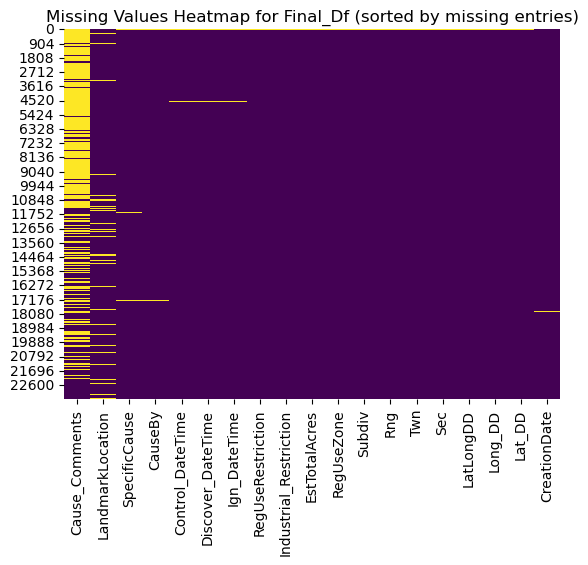

In [45]:
# Heatmap of missing values
# Hint: sns.heatmap(df.isna(), ...)
missing_pct = final_df.isna().mean().sort_values(ascending=False)
cols_sorted = missing_pct[missing_pct > 0].index
sns.heatmap(final_df[cols_sorted].isna(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap for Final_Df (sorted by missing entries)")
plt.show()

This data shows that most of the columns in our primary dataset were in fact there. It helps also visualize that most of this dataset is complete, though one column, `CAUSE_COMMENTS` is missing many entries, likely because of lack of commentary. However, because of the lack of many missing values, it was ultimately decided to keep the missing values columns, and fill in what was missing with strings to indicate such.

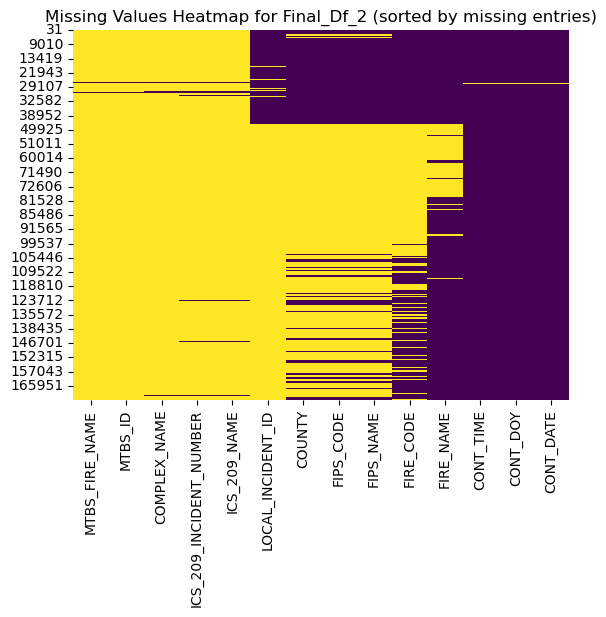

In [44]:
missing_pct_2 = final_df_2.isna().mean().sort_values(ascending=False)
cols_sorted_2 = missing_pct_2[missing_pct_2 > 0].index 
sns.heatmap(final_df_2[cols_sorted_2].isna(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap for Final_Df_2 (sorted by missing entries)")
plt.show()

From this heatmap, we can see our Kaggle dataset had many columns missing almost all their data. because of this, many of these columns were cut, in order to cut down the size of the data being cleaned, and because these columns seem unnessecary due to how much data was missing.

From the dataset from the ODF, there 19 columns with missing values,
though it ranges from having only tens missing out of thousands, to having tens of thousands missing,
though this only applies to one column. None of the columns are missing such an outrageous amount of data,
so replacing the missing values will be the main priority.

As for the dataset from Kaggle, there are 16 datasets with missing data, 
and unlike the dataset from the ODF, of these, 5 have almost no entries,
and 8-9 are very incomplete-seeming. We will drop all the columns with missing data from the kaggle dataset,
as the amount of missing data would only serve to hinder the process of analysis.

The datasets had inconsistent naming convention with each other as well, which needed to be changed. Even though it was our primary dataset, we changed its names to match our secondary data tables' column names, as they had more conventional allcaps column names, rather than inconsistent capitalizations in our primary.

In [16]:
# Handle missing values
odf_with_missing = final_df.fillna('None/Missing') # filling missing columns
odf_with_missing

,Serial,FireCategory,FireYear,Area,DistrictName,UnitName,FullFireNumber,FireName,Size_class,EstTotalAcres,...,Industrial_Restriction,Ign_DateTime,ReportDateTime,Discover_DateTime,Control_DateTime,CreationDate,ModifiedDate,DistrictCode,UnitCode,DistFireNumber
0,108204,STAT,2017,EOA,Klamath-Lake,Lakeview,17-982068-18,Castle 483,A,None/Missing,...,None/Missing,None/Missing,08/08/2017 12:53:00 PM,None/Missing,None/Missing,08/08/2017 12:00:00 AM,08/08/2017 02:11:00 PM,98,982,068
1,68272,STAT,2003,NOA,North Cascade,Santiam,03-582216-04,Marion Forks Move Up,A,0.0,...,Unspecified,None/Missing,09/02/2003 12:00:00 AM,None/Missing,None/Missing,09/03/2003 01:43:00 PM,08/23/2011 04:20:00 PM,58,582,216
2,75461,STAT,2006,EOA,Klamath-Lake,Klamath,06-981055-07,BUCK,A,0.1,...,Lvl 4 Complete Shutdown,08/05/2006 03:00:00 PM,08/05/2006 03:45:00 PM,08/05/2006 03:42:00 PM,08/05/2006 06:00:00 PM,08/08/2006 07:43:00 PM,09/16/2006 04:31:00 PM,98,981,055
3,98874,STAT,2014,NOA,Forest Grove,Columbia City,14-532076-15,Hafferman Rd. #1,A,0.1,...,Lvl 2 Limited Shutdown,None/Missing,09/04/2014 02:20:00 PM,None/Missing,09/04/2014 02:40:00 PM,09/04/2014 12:00:00 AM,09/05/2014 11:28:00 AM,53,532,076
4,112552,STAT,2017,NOA,North Cascade,Santiam,17-582069-18,Lyons Preposition,A,None/Missing,...,None/Missing,None/Missing,09/12/2017 08:00:00 AM,None/Missing,None/Missing,08/29/2018 12:00:00 AM,08/29/2018 12:44:00 PM,58,582,069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,124548,STAT,2021,EOA,Walker Range - WRFPA,Crescent,21-991258-21,Road 2430,B,0.75,...,Does Not Apply - Eastern OR,06/26/2021 04:00:00 PM,06/26/2021 04:58:00 PM,06/26/2021 04:45:00 PM,06/26/2021 09:58:00 PM,07/01/2021 12:00:00 AM,10/02/2021 03:08:00 PM,99,991,258
23486,132141,STAT,2022,SOA,Western Lane,Veneta,22-781066-23,Spruce Path,A,0.01,...,Lvl 1 Fire Season Only,09/13/2022 11:20:00 AM,09/13/2022 11:20:00 AM,09/13/2022 11:20:00 AM,09/13/2022 12:14:00 PM,09/13/2022 12:00:00 AM,09/19/2022 10:09:00 AM,78,781,066
23487,124065,STAT,2021,EOA,Northeast Oregon,Pendleton,21-973052-21,Bone Canyon,C,67.43,...,Does Not Apply - Eastern OR,06/13/2021 05:22:00 PM,06/14/2021 12:45:00 PM,06/14/2021 12:45:00 PM,06/17/2021 05:10:00 PM,06/14/2021 12:00:00 AM,09/24/2021 01:48:00 PM,97,973,052
23488,131292,STAT,2022,EOA,Northeast Oregon,Pendleton,22-973014-23,Milepost 231,A,0.1,...,Does Not Apply - Eastern OR,08/19/2022 03:09:00 PM,08/19/2022 03:09:00 PM,08/19/2022 03:09:00 PM,08/19/2022 04:41:00 PM,08/19/2022 12:00:00 AM,11/08/2022 11:34:00 AM,97,973,014


In [17]:
kaggle_without_missing = final_df_2.dropna(axis=1) # dropping missing columns
kaggle_without_missing

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,STAT_CAUSE_CODE,STAT_CAUSE_DESCR,FIRE_SIZE,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,Shape
31,32,32,FS-1418907,FED,FS-FIRESTAT,FS,USORDEF,Deschutes National Forest,0601,Deschutes National Forest,...,4.0,Campfire,0.1,A,43.995556,-121.414167,13.0,STATE OR PRIVATE,OR,AAGtEAAAkK/rtIFaXsCQxlVdbv9FQJCv67SBWl7AkMZVXW...
35,36,36,FS-1418916,FED,FS-FIRESTAT,FS,USORDEF,Deschutes National Forest,0601,Deschutes National Forest,...,4.0,Campfire,0.1,A,44.043333,-121.386111,5.0,USFS,OR,AAGtEAAAnIRfC7ZYXsCollHyiwVGQJyEXwu2WF7AqJZR8o...
43,44,44,FS-1418924,FED,FS-FIRESTAT,FS,USORDEF,Deschutes National Forest,0601,Deschutes National Forest,...,4.0,Campfire,0.1,A,43.955556,-121.352222,5.0,USFS,OR,AAGtEAAAxPQQz4pWXsAI2wOlT/pFQMT0EM+KVl7ACNsDpU...
46,47,47,FS-1418935,FED,FS-FIRESTAT,FS,USORUMF,Umatilla National Forest,0614,Umatilla National Forest,...,9.0,Miscellaneous,5.0,B,44.911111,-119.696111,5.0,USFS,OR,AAGtEAAAQPWcFY3sXcB4PPJJn3RGQED1nBWN7F3AeDzySZ...
48,49,49,FS-1418943,FED,FS-FIRESTAT,FS,USORDEF,Deschutes National Forest,0601,Deschutes National Forest,...,4.0,Campfire,0.1,A,43.725278,-121.574167,5.0,USFS,OR,AAGtEAAAmIaPJb9kXsDQzvzm1dxFQJiGjyW/ZF7A0M785t...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171597,171598,173277,FS-402097,FED,FS-FIRESTAT,FS,USORUPF,Umpqua National Forest,0615,Umpqua National Forest,...,4.0,Campfire,0.1,A,43.582222,-122.717778,5.0,USFS,OR,AAGtEAAATLk2EvCtXsDQ8/hBhspFQEy5NhLwrV7A0PP4QY...
171598,171599,173278,FS-402098,FED,FS-FIRESTAT,FS,USORUPF,Umpqua National Forest,0615,Umpqua National Forest,...,1.0,Lightning,0.1,A,43.365278,-122.215556,5.0,USFS,OR,AAGtEAAA8CqMqcuNXsAghxtswa5FQPAqjKnLjV7AIIcbbM...
171599,171600,173279,FS-402099,FED,FS-FIRESTAT,FS,USORUPF,Umpqua National Forest,0615,Umpqua National Forest,...,1.0,Lightning,0.5,B,43.366944,-122.303611,5.0,USFS,OR,AAGtEAAAvAlLXW6TXsDonxAJ+K5FQLwJS11uk17A6J8QCf...
171600,171601,173280,FS-402100,FED,FS-FIRESTAT,FS,USORUPF,Umpqua National Forest,0615,Umpqua National Forest,...,1.0,Lightning,0.1,A,43.281389,-122.080556,5.0,USFS,OR,AAGtEAAAgO2B0ieFXsAIARiNBKRFQIDtgdInhV7ACAEYjQ...


In [18]:
# Rename columns

new_names = ['SERIAL','FIRE_CATEGORY','FIRE_YEAR','DISTRICT_NAME','FULL_FIRE_NUMBER','UNIT_NAME','FIRE_NAME','SIZE_CLASS','EST_TOTAL_ACRES','HUMAN_OR_LIGHTNING','CAUSE_BY','GENERAL_CAUSE','SPECIFIC_CAUSE',
            'FO_LAND_OWN_TYPE','LANDMARK_LOCATION','REG_USE_ZONE','REG_USE_RESTRICTION','REPORT_DATE_TIME','DISCOVER_DATE_TIME','CONTROL_DATE_TIME','CREATION_DATE','MODIFIED_DATE',
             'DISTRICT_CODE','UNIT_CODE','DIST_FIRE_NUMBER','IGN_DATE_TIME','AREA','TWN','RNG','SEC','SUBDIV','COUNTY','LAT_LONG_DD','LONGITUDE','LATITUDE', 'PROTECTED_ACRES','CAUSE_COMMENTS']
old_names = ['Serial','FireCategory','FireYear','DistrictName','FullFireNumber','UnitName','FireName','Size_class','EstTotalAcres','HumanOrLightning','CauseBy','GeneralCause','SpecificCause','FO_LandOwnType',
             'LandmarkLocation','RegUseZone','RegUseRestriction','ReportDateTime','Discover_DateTime','Control_DateTime','CreationDate','ModifiedDate','DistrictCode','UnitCode',
             'DistFireNumber','Ign_DateTime','Area','Twn','Rng','Sec','Subdiv','County','LatLongDD','Long_DD','Lat_DD', 'Protected_Acres','Cause_Comments']
odf_renamed = odf_with_missing.rename(columns=dict(zip(old_names, new_names)))
odf_renamed

,SERIAL,FIRE_CATEGORY,FIRE_YEAR,AREA,DISTRICT_NAME,UNIT_NAME,FULL_FIRE_NUMBER,FIRE_NAME,SIZE_CLASS,EST_TOTAL_ACRES,...,Industrial_Restriction,IGN_DATE_TIME,REPORT_DATE_TIME,DISCOVER_DATE_TIME,CONTROL_DATE_TIME,CREATION_DATE,MODIFIED_DATE,DISTRICT_CODE,UNIT_CODE,DIST_FIRE_NUMBER
0,108204,STAT,2017,EOA,Klamath-Lake,Lakeview,17-982068-18,Castle 483,A,None/Missing,...,None/Missing,None/Missing,08/08/2017 12:53:00 PM,None/Missing,None/Missing,08/08/2017 12:00:00 AM,08/08/2017 02:11:00 PM,98,982,068
1,68272,STAT,2003,NOA,North Cascade,Santiam,03-582216-04,Marion Forks Move Up,A,0.0,...,Unspecified,None/Missing,09/02/2003 12:00:00 AM,None/Missing,None/Missing,09/03/2003 01:43:00 PM,08/23/2011 04:20:00 PM,58,582,216
2,75461,STAT,2006,EOA,Klamath-Lake,Klamath,06-981055-07,BUCK,A,0.1,...,Lvl 4 Complete Shutdown,08/05/2006 03:00:00 PM,08/05/2006 03:45:00 PM,08/05/2006 03:42:00 PM,08/05/2006 06:00:00 PM,08/08/2006 07:43:00 PM,09/16/2006 04:31:00 PM,98,981,055
3,98874,STAT,2014,NOA,Forest Grove,Columbia City,14-532076-15,Hafferman Rd. #1,A,0.1,...,Lvl 2 Limited Shutdown,None/Missing,09/04/2014 02:20:00 PM,None/Missing,09/04/2014 02:40:00 PM,09/04/2014 12:00:00 AM,09/05/2014 11:28:00 AM,53,532,076
4,112552,STAT,2017,NOA,North Cascade,Santiam,17-582069-18,Lyons Preposition,A,None/Missing,...,None/Missing,None/Missing,09/12/2017 08:00:00 AM,None/Missing,None/Missing,08/29/2018 12:00:00 AM,08/29/2018 12:44:00 PM,58,582,069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,124548,STAT,2021,EOA,Walker Range - WRFPA,Crescent,21-991258-21,Road 2430,B,0.75,...,Does Not Apply - Eastern OR,06/26/2021 04:00:00 PM,06/26/2021 04:58:00 PM,06/26/2021 04:45:00 PM,06/26/2021 09:58:00 PM,07/01/2021 12:00:00 AM,10/02/2021 03:08:00 PM,99,991,258
23486,132141,STAT,2022,SOA,Western Lane,Veneta,22-781066-23,Spruce Path,A,0.01,...,Lvl 1 Fire Season Only,09/13/2022 11:20:00 AM,09/13/2022 11:20:00 AM,09/13/2022 11:20:00 AM,09/13/2022 12:14:00 PM,09/13/2022 12:00:00 AM,09/19/2022 10:09:00 AM,78,781,066
23487,124065,STAT,2021,EOA,Northeast Oregon,Pendleton,21-973052-21,Bone Canyon,C,67.43,...,Does Not Apply - Eastern OR,06/13/2021 05:22:00 PM,06/14/2021 12:45:00 PM,06/14/2021 12:45:00 PM,06/17/2021 05:10:00 PM,06/14/2021 12:00:00 AM,09/24/2021 01:48:00 PM,97,973,052
23488,131292,STAT,2022,EOA,Northeast Oregon,Pendleton,22-973014-23,Milepost 231,A,0.1,...,Does Not Apply - Eastern OR,08/19/2022 03:09:00 PM,08/19/2022 03:09:00 PM,08/19/2022 03:09:00 PM,08/19/2022 04:41:00 PM,08/19/2022 12:00:00 AM,11/08/2022 11:34:00 AM,97,973,014


In [19]:
kaggle_renamed = kaggle_without_missing.rename(columns={"Shape": "SHAPE", 
                                                        "STAT_CAUSE_DESCR": 
                                                        "SPECIFIC_CAUSE", 
                                                        "FIRE_SIZE_CLASS": "SIZE_CLASS",
                                                        "NWCG_REPORTING_UNIT_NAME": "UNIT_NAME", 
                                                        'FIRE_SIZE': 'EST_TOTAL_ACRES'
                                                       })

## Fixing Dtypes

There were 4 columns in the primary data set that needed to be changed. They were originally float64 but due to filling empty rows in the tables earlier in the cleaning process, had become object cols.

In [48]:
cols = ['LATITUDE', 'LONGITUDE', 'SEC', 'EST_TOTAL_ACRES']

odf_renamed[cols] = odf_renamed[cols].replace("None/Missing", np.nan) # changes the strings to NaN values

odf_renamed[cols] = odf_renamed[cols].apply(pd.to_numeric)   # changes the dtypes from objects to floats

print(odf_renamed[cols].dtypes) # prints off the dtypes of the changed rows.

LATITUDE           float64
LONGITUDE          float64
SEC                float64
EST_TOTAL_ACRES    float64
dtype: object


## Standardize String Values

In both datasets, there were some columns that needed to be cleaned before merging. Some were left uncleaned, as they are going to be removed later on, but in particular, we needed to clean `FIRE_NAME`, `GENERAL_CAUSE`, `HUMAN_OR_LIGHTNING`, `UNIT_NAME`, and `SIZE_CLASS` from the Oregon Fire Department database, as well as `SIZE_CLASS`, `UNIT_NAME` and `SPECIFIC_CAUSE` from the Kaggle database.

In [49]:
string_cols_odf = [ # strings that were changed
    'FIRE_NAME',
    'GENERAL_CAUSE',
    'SPECIFIC_CAUSE',
    'HUMAN_OR_LIGHTNING',
    'UNIT_NAME',
    'SIZE_CLASS',
]

for col in string_cols_odf:
    odf_renamed[col] = (
        odf_renamed[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )
odf_renamed.head()

,SERIAL,FIRE_CATEGORY,FIRE_YEAR,AREA,DISTRICT_NAME,UNIT_NAME,FULL_FIRE_NUMBER,FIRE_NAME,SIZE_CLASS,EST_TOTAL_ACRES,...,Industrial_Restriction,IGN_DATE_TIME,REPORT_DATE_TIME,DISCOVER_DATE_TIME,CONTROL_DATE_TIME,CREATION_DATE,MODIFIED_DATE,DISTRICT_CODE,UNIT_CODE,DIST_FIRE_NUMBER
0,108204,STAT,2017,EOA,klamath-lake,lakeview,17-982068-18,castle 483,a,NaN,...,None/Missing,NaT,2017-08-08 12:53:00,NaT,NaT,2017-08-08 00:00:00,2017-08-08 14:11:00,98,982,068
1,68272,STAT,2003,NOA,north cascade,santiam,03-582216-04,marion forks move up,a,0.0,...,Unspecified,NaT,2003-09-02 00:00:00,NaT,NaT,2003-09-03 13:43:00,2011-08-23 16:20:00,58,582,216
2,75461,STAT,2006,EOA,klamath-lake,klamath,06-981055-07,buck,a,0.1,...,Lvl 4 Complete Shutdown,2006-08-05 15:00:00,2006-08-05 15:45:00,2006-08-05 15:42:00,2006-08-05 18:00:00,2006-08-08 19:43:00,2006-09-16 16:31:00,98,981,055
3,98874,STAT,2014,NOA,forest grove,columbia city,14-532076-15,hafferman rd. #1,a,0.1,...,Lvl 2 Limited Shutdown,NaT,2014-09-04 14:20:00,NaT,2014-09-04 14:40:00,2014-09-04 00:00:00,2014-09-05 11:28:00,53,532,076
4,112552,STAT,2017,NOA,north cascade,santiam,17-582069-18,lyons preposition,a,NaN,...,None/Missing,NaT,2017-09-12 08:00:00,NaT,NaT,2018-08-29 00:00:00,2018-08-29 12:44:00,58,582,069


In [50]:
string_cols_kaggle = [
    'SPECIFIC_CAUSE',
    'SIZE_CLASS',
    'UNIT_NAME'
]

for col in string_cols_kaggle:
    kaggle_renamed[col] = (
        kaggle_renamed[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )
kaggle_renamed.head()

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,SPECIFIC_CAUSE,EST_TOTAL_ACRES,SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,SHAPE,DISCOVER_DATE_TIME
31,32,32,FS-1418907,FED,FS-FIRESTAT,FS,USORDEF,deschutes national forest,0601,Deschutes National Forest,...,campfire,0.1,a,43.995556,-121.414167,13.0,STATE OR PRIVATE,OR,AAGtEAAAkK/rtIFaXsCQxlVdbv9FQJCv67SBWl7AkMZVXW...,1970-01-01 09:43:00
35,36,36,FS-1418916,FED,FS-FIRESTAT,FS,USORDEF,deschutes national forest,0601,Deschutes National Forest,...,campfire,0.1,a,44.043333,-121.386111,5.0,USFS,OR,AAGtEAAAnIRfC7ZYXsCollHyiwVGQJyEXwu2WF7AqJZR8o...,1970-01-01 10:42:00
43,44,44,FS-1418924,FED,FS-FIRESTAT,FS,USORDEF,deschutes national forest,0601,Deschutes National Forest,...,campfire,0.1,a,43.955556,-121.352222,5.0,USFS,OR,AAGtEAAAxPQQz4pWXsAI2wOlT/pFQMT0EM+KVl7ACNsDpU...,1970-01-01 12:05:00
46,47,47,FS-1418935,FED,FS-FIRESTAT,FS,USORUMF,umatilla national forest,0614,Umatilla National Forest,...,miscellaneous,5.0,b,44.911111,-119.696111,5.0,USFS,OR,AAGtEAAAQPWcFY3sXcB4PPJJn3RGQED1nBWN7F3AeDzySZ...,1970-01-01 10:00:00
48,49,49,FS-1418943,FED,FS-FIRESTAT,FS,USORDEF,deschutes national forest,0601,Deschutes National Forest,...,campfire,0.1,a,43.725278,-121.574167,5.0,USFS,OR,AAGtEAAAmIaPJb9kXsDQzvzm1dxFQJiGjyW/ZF7A0M785t...,1970-01-01 15:35:00


## Converting Datetime Columns

There was a notable amount of datetimes in each table, so we converted them all to `datetime` dtypes. This conversion is going to be useful later when column engineering and creating visuals for this data. Some ended up being cut, but most notable, `DISCOVERY_DATE` and `DISCOVERY_TIME` would be engineered into a new column `DISCOVERY_DATE_TIME` for the Kaggle dataset, to merge with the same column from the ODF dataset.

In [23]:

date_cols = [     # columns being converted
    'IGN_DATE_TIME',
    'REPORT_DATE_TIME',
    'DISCOVER_DATE_TIME',
    'CONTROL_DATE_TIME',
    'CREATION_DATE',
    'MODIFIED_DATE'
]

odf_renamed[date_cols] = (
    odf_renamed[date_cols]
    .replace("None/Missing", np.nan)  # replaces the none/missing with proper nan values.
)

for col in date_cols:
    odf_renamed[col] = pd.to_datetime(
        odf_renamed[col],
        format = '%m/%d/%Y %I:%M:%S %p', # using regular expression to describe the dates of the columns.
        errors='coerce'    # forces the change even if theres no date, so the rows are consistent.
    )


odf_renamed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   SERIAL                  23490 non-null  int64         
 1   FIRE_CATEGORY           23490 non-null  object        
 2   FIRE_YEAR               23490 non-null  int64         
 3   AREA                    23490 non-null  object        
 4   DISTRICT_NAME           23490 non-null  object        
 5   UNIT_NAME               23490 non-null  object        
 6   FULL_FIRE_NUMBER        23490 non-null  object        
 7   FIRE_NAME               23490 non-null  object        
 8   SIZE_CLASS              23490 non-null  object        
 9   EST_TOTAL_ACRES         23411 non-null  float64       
 10  PROTECTED_ACRES         23490 non-null  float64       
 11  HUMAN_OR_LIGHTNING      23490 non-null  object        
 12  CAUSE_BY                23490 non-null  object

In [24]:
kaggle_renamed['DISCOVERY_DATE'] = pd.to_datetime(
    kaggle_renamed['DISCOVERY_DATE'],
    errors='coerce'
)
kaggle_renamed['DISCOVERY_TIME'] = (
    kaggle_renamed['DISCOVERY_TIME']
    .astype(str)
    .str.zfill(4)  
)
kaggle_renamed['DISCOVER_DATE_TIME'] = pd.to_datetime(     # making a new column to be merged onto
    kaggle_renamed['DISCOVERY_DATE'].dt.strftime('%Y-%m-%d') + ' ' +  # regex 
    kaggle_renamed['DISCOVERY_TIME'].str[:2] + ':' +
    kaggle_renamed['DISCOVERY_TIME'].str[2:],
    errors='coerce'
)

kaggle_renamed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20841 entries, 31 to 171637
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   OBJECTID                    20841 non-null  int64         
 1   FOD_ID                      20841 non-null  int64         
 2   FPA_ID                      20841 non-null  object        
 3   SOURCE_SYSTEM_TYPE          20841 non-null  object        
 4   SOURCE_SYSTEM               20841 non-null  object        
 5   NWCG_REPORTING_AGENCY       20841 non-null  object        
 6   NWCG_REPORTING_UNIT_ID      20841 non-null  object        
 7   UNIT_NAME                   20841 non-null  object        
 8   SOURCE_REPORTING_UNIT       20841 non-null  object        
 9   SOURCE_REPORTING_UNIT_NAME  20841 non-null  object        
 10  LOCAL_FIRE_REPORT_ID        20841 non-null  int64         
 11  FIRE_YEAR                   20841 non-null  int64        

## Merging

We decided to first join using outer, to keep all the data we can given some rows may not merge perfectly, changing later as needed. We joined on `FIRE_YEAR`, `SIZE_CLASS`,
`LATITUDE`, `LONGITUDE`, `SPECIFIC_CAUSE`, and `UNIT_NAME`, since they were the only columns visually and in terms of their information, similar enough to merge completely without issues.
If this does change later, we will likely include merging the dates of discovery columns in each data set, for engineering purposes.

Following more work on it, we also included `DISCOVER_DATE_TIME` and `EST_TOTAL_ACRES`, as they are both relevant to my work and mergeable. We also decided to merge left, as the ODF
fire database is my primary dataset here.

In [25]:
merged_df = pd.merge(
    odf_renamed,
    kaggle_renamed,
    on=['FIRE_YEAR', 'SIZE_CLASS', 'LATITUDE', 'LONGITUDE', 'SPECIFIC_CAUSE', 'UNIT_NAME', 'DISCOVER_DATE_TIME', 'EST_TOTAL_ACRES'],
    how='left'
)
merged_df.info()
merged_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 56 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   SERIAL                      23490 non-null  int64         
 1   FIRE_CATEGORY               23490 non-null  object        
 2   FIRE_YEAR                   23490 non-null  int64         
 3   AREA                        23490 non-null  object        
 4   DISTRICT_NAME               23490 non-null  object        
 5   UNIT_NAME                   23490 non-null  object        
 6   FULL_FIRE_NUMBER            23490 non-null  object        
 7   FIRE_NAME                   23490 non-null  object        
 8   SIZE_CLASS                  23490 non-null  object        
 9   EST_TOTAL_ACRES             23411 non-null  float64       
 10  PROTECTED_ACRES             23490 non-null  float64       
 11  HUMAN_OR_LIGHTNING          23490 non-null  object    

(23490, 56)

## Row filtering

We decided to remove a lot of rows, given many were not significant to the dataset and due to the merge, many were now empty. Below are all rows that were all related to more logistical information on the fire department's end, or simply not found to be useful for visualizing and utilizing our dataset. 

In [26]:
cols_to_drop = [
    'PROTECTED_ACRES', 'FIRE_CATEGORY', 'AREA', 'REG_USE_RESTRICTION', 'Industrial_Restriction', 'IGN_DATE_TIME', 'REPORT_DATE_TIME',
    'REG_USE_ZONE', 'REG_USE_RESTRICTION', 'COUNTY', 'SEC', 'SUBDIV', 'LANDMARK_LOCATION', 'FO_LAND_OWN_TYPE', 'CREATION_DATE', 'MODIFIED_DATE',
    'DISTRICT_CODE', 'UNIT_CODE', 'TWN', 'RNG', 'FULL_FIRE_NUMBER', 'STATE', 'SHAPE', 'OWNER_DESCR', 'OWNER_CODE', 'STAT_CAUSE_CODE', 'DISCOVERY_TIME',
    'DISCOVERY_DATE', 'DISCOVERY_DOY', 'LOCAL_FIRE_REPORT_ID', 'SOURCE_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT', 'NWCG_REPORTING_UNIT_ID', 
    'NWCG_REPORTING_AGENCY', 'SOURCE_SYSTEM', 'SOURCE_SYSTEM_TYPE', 'FOD_ID', 'FPA_ID', 'OBJECT_ID'
               ]
merged_df = merged_df.drop(cols_to_drop, axis=1)
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   SERIAL                      23490 non-null  int64         
 1   FIRE_YEAR                   23490 non-null  int64         
 2   DISTRICT_NAME               23490 non-null  object        
 3   UNIT_NAME                   23490 non-null  object        
 4   FIRE_NAME                   23490 non-null  object        
 5   SIZE_CLASS                  23490 non-null  object        
 6   EST_TOTAL_ACRES             23411 non-null  float64       
 7   HUMAN_OR_LIGHTNING          23490 non-null  object        
 8   CAUSE_BY                    23490 non-null  object        
 9   GENERAL_CAUSE               23490 non-null  object        
 10  SPECIFIC_CAUSE              23490 non-null  object        
 11  CAUSE_COMMENTS              23490 non-null  object    

<a id="summary-stats"></a>
---
## Summary Statistics 

Below are some of the statistics we got from merging our data, showing that the merge on the primary dataset was a success, though some columns are missing values for `EST_TOTAL_ACRES`.

In [27]:
merged_df.shape
merged_df.info()
merged_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   SERIAL                      23490 non-null  int64         
 1   FIRE_YEAR                   23490 non-null  int64         
 2   DISTRICT_NAME               23490 non-null  object        
 3   UNIT_NAME                   23490 non-null  object        
 4   FIRE_NAME                   23490 non-null  object        
 5   SIZE_CLASS                  23490 non-null  object        
 6   EST_TOTAL_ACRES             23411 non-null  float64       
 7   HUMAN_OR_LIGHTNING          23490 non-null  object        
 8   CAUSE_BY                    23490 non-null  object        
 9   GENERAL_CAUSE               23490 non-null  object        
 10  SPECIFIC_CAUSE              23490 non-null  object        
 11  CAUSE_COMMENTS              23490 non-null  object    

,SERIAL,FIRE_YEAR,DISTRICT_NAME,UNIT_NAME,FIRE_NAME,SIZE_CLASS,EST_TOTAL_ACRES,HUMAN_OR_LIGHTNING,CAUSE_BY,GENERAL_CAUSE,...,SOURCE_REPORTING_UNIT_NAME,LOCAL_FIRE_REPORT_ID,DISCOVERY_DATE,DISCOVERY_DOY,DISCOVERY_TIME,STAT_CAUSE_CODE,OWNER_CODE,OWNER_DESCR,STATE,SHAPE
0,108204,2017,klamath-lake,lakeview,castle 483,a,NaN,under invest,None/Missing,under invest,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,68272,2003,north cascade,santiam,marion forks move up,a,0.0,human,Recreationist,smoking,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,75461,2006,klamath-lake,klamath,buck,a,0.1,lightning,Lightning,lightning,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,98874,2014,forest grove,columbia city,hafferman rd. #1,a,0.1,human,Ruralist-Paying,debris burning,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,112552,2017,north cascade,santiam,lyons preposition,a,NaN,human,None/Missing,miscellaneous,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
merged_df.describe()

,SERIAL,FIRE_YEAR,EST_TOTAL_ACRES,LATITUDE,LONGITUDE,DISCOVER_DATE_TIME,CONTROL_DATE_TIME,OBJECTID,FOD_ID,LOCAL_FIRE_REPORT_ID,DISCOVERY_DATE,DISCOVERY_DOY,STAT_CAUSE_CODE,OWNER_CODE
count,23490.000000,23490.00000,23411.000000,23480.000000,23480.000000,23396,23395,0.0,0.0,0.0,0,0.0,0.0,0.0
mean,90425.933461,2010.80132,270.802503,43.718410,-122.258736,2011-05-07 22:06:38.955377152,2011-05-12 04:56:53.926907392,NaN,NaN,NaN,NaT,NaN,NaN,NaN
min,57485.000000,2000.00000,0.000000,41.089460,-124.983610,2000-03-13 14:00:00,2000-03-13 15:01:00,NaN,NaN,NaN,NaT,NaN,NaN,NaN
25%,72508.500000,2005.00000,0.010000,42.526093,-123.387420,2005-08-02 11:03:30,2005-08-03 11:45:00,NaN,NaN,NaN,NaT,NaN,NaN,NaN
50%,88340.000000,2011.00000,0.100000,43.581805,-122.847220,2011-06-21 07:37:00,2011-06-23 12:10:00,NaN,NaN,NaN,NaT,NaN,NaN,NaN
75%,107432.500000,2017.00000,0.500000,44.789518,-121.541827,2017-07-10 00:07:00,2017-07-12 13:28:00,NaN,NaN,NaN,NaT,NaN,NaN,NaN
max,134021.000000,2022.00000,499945.000000,46.235000,-116.521110,2022-11-27 11:15:00,2077-08-28 23:00:00,NaN,NaN,NaN,NaT,NaN,NaN,NaN
std,20901.016028,6.73508,6816.736966,1.226385,1.707589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


What the summary tells us is that the mean size of fires was actually relatively small, below an acre,
and that the maximum fire size was almost 500 thousand acres. The standard deviation for fire size, however, is around 6800 acres, and the total amount of fires which had their size recorded was 23411, short a few rows of our total count of fires. It tells also seems to tell us from the `DISCOVER_DATE_TIME` and `CONTROL_DATE_TIME` columns that the average amount of time it took to put out a fire was 5 hours, though, we can verify if thats actually the case through column engineering. This doesn't answer our research question, though, so we must keep working on engineering the data to investigate what we are looking for.

<a id="column-engineering"></a>
---
## Column Engineering


We decided on a new column, known as `FIRE_SIZE_GROUP`, which groups fires based on size and severity with .apply and lambda. This column can be useful in determining how great the severity of 
human-made fires is vs non-human fires, with the assistance of our other columns. It will also go on to help us visualize some of our data later.

In [29]:
merged_df['FIRE_SIZE_GROUP'] = merged_df['EST_TOTAL_ACRES'].apply(
    lambda x: 'Small' if x < 1
    else 'Medium' if x < 100
    else 'Large'
)

Another new column is `CONTAINMENT_TIME`, for tracking how long it took the tracked fires to be contained and put out, in measurements of hours. 
Alongside our new `FIRE_SIZE_GROUP` table, this helps us track how long human-made fires vs natural fires last, and whether in more recent years, the time it takes 
to put out those fires has gone up.

One notable issue with *some* parts of this column, however, is the extreme ends, both large and small, as well as some fires with missing time values, have negative, NaN, or incredulous hours listed on their containment date. This could be modified with more work, but it seems to be only for a few cases.
                                                                                                                                                                                                                                                                                                  
                                                                                                                                                                                                        

In [30]:
merged_df['CONTAINMENT_TIME'] = (
    merged_df['CONTROL_DATE_TIME'] - merged_df['DISCOVER_DATE_TIME']
).dt.total_seconds() / 3600

In [31]:
merged_df[['FIRE_SIZE_GROUP', 'CONTAINMENT_TIME']]

,FIRE_SIZE_GROUP,CONTAINMENT_TIME
0,Large,NaN
1,Small,NaN
2,Small,2.300000
3,Small,NaN
4,Large,NaN
...,...,...
23485,Small,5.216667
23486,Small,0.900000
23487,Medium,76.416667
23488,Small,1.533333


## Visuals
Now that we have merged the data, what might we do with it to better present it to the class? For this section, we had a very specific idea of what we wanted to show off with our findings that may not have been immediately obvious within the data itself. But rather than talk about it, it may be better to just let the visuals speak for themselves.

### Visual 1

This plot visualizes fires geographically across Oregon, both human and natural ones, to find if there are any patterns in where they tend to happen.

Text(0.5, 1.0, 'Wildfire Causes by Geographic Location')

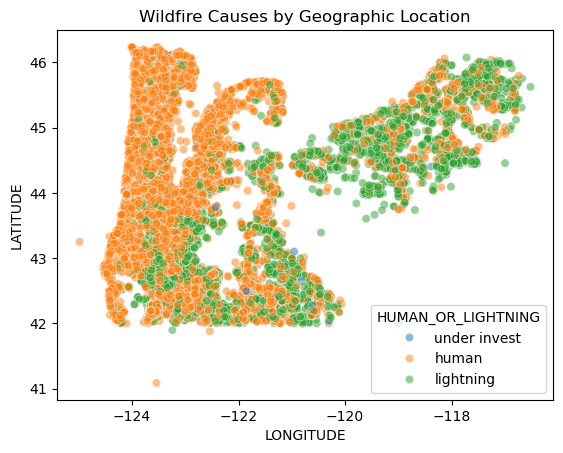

In [42]:
sns.scatterplot(
    data=merged_df,
    x='LONGITUDE',
    y='LATITUDE',
    hue='HUMAN_OR_LIGHTNING',
    alpha=0.5,
    palette="tab10"
)
plt.title('Wildfire Causes by Geographic Location')

This plot helps visualize where most human vs most naturally-caused fires occur. Much of the human-caused fires are along the populated, forested coast or along large population centers, like Eugene or Portland. Many non-human fires, however, tend to happen very inland, near the northeast forests, or the heavily-forested southern central Oregon, and there we see overlap along population centers like Grant's Pass or Medford.

### Visual 2

This plot intends to show the difference in wildfire severity over time, in acres burned. The intent is to show that there is a noticeable increase in fire severity over time.

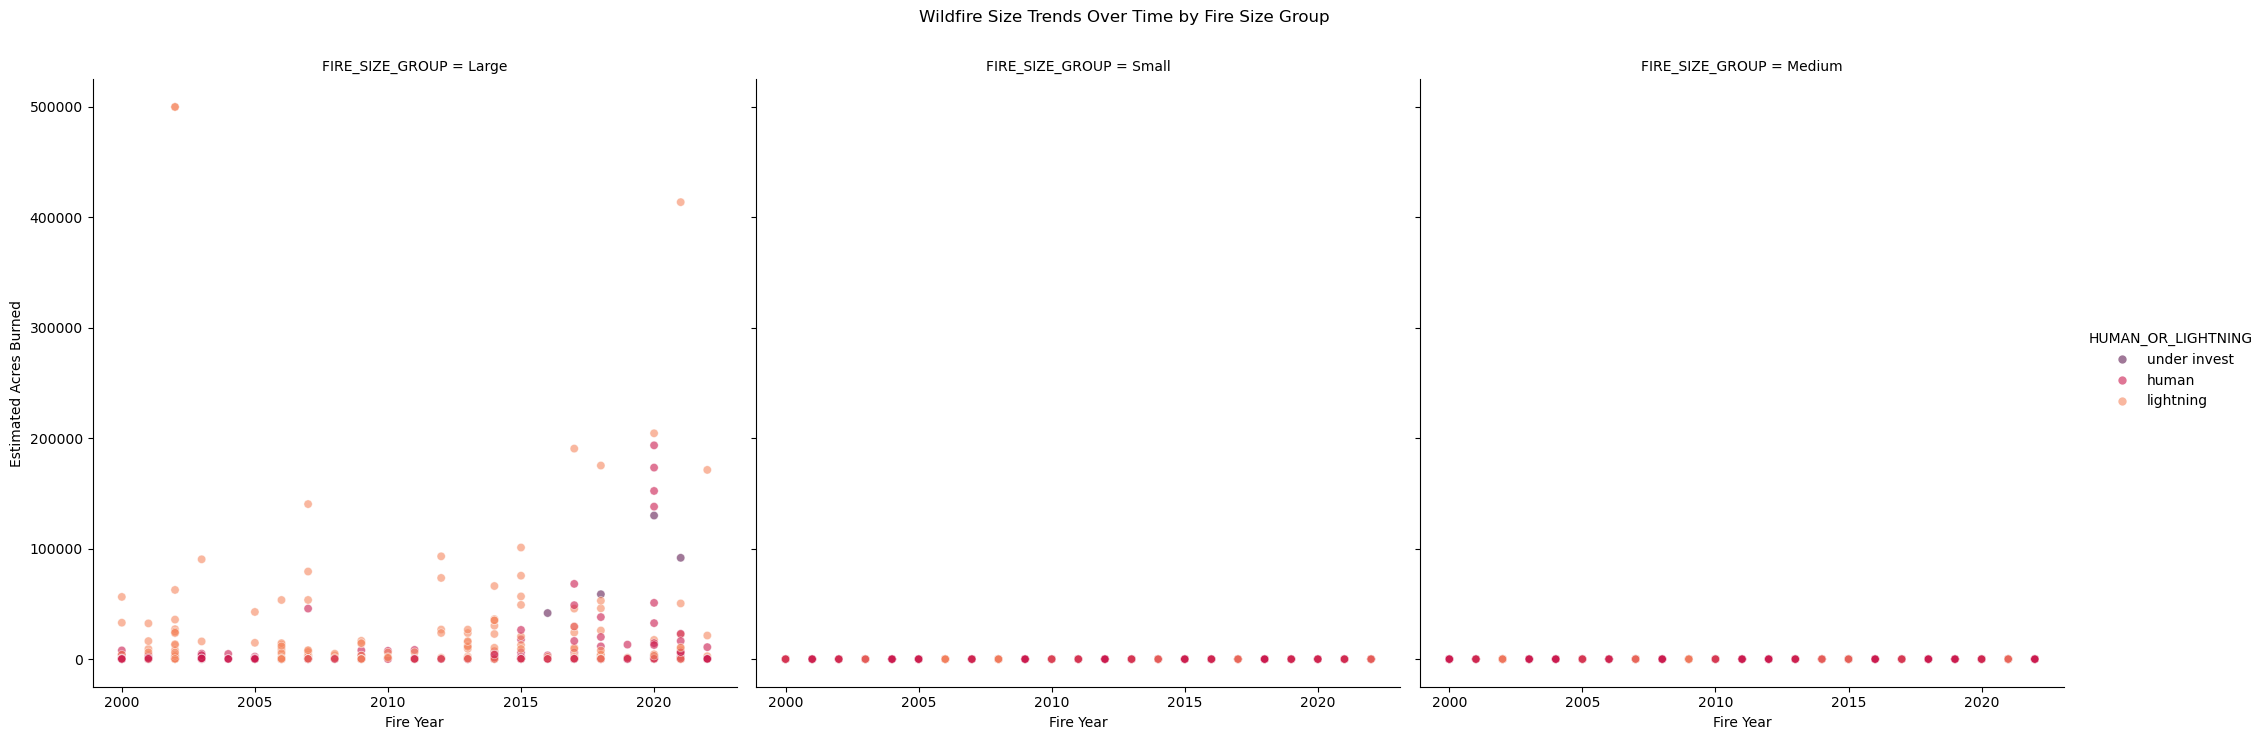

In [33]:
g = sns.relplot(
    data=merged_df,
    x='FIRE_YEAR',
    y='EST_TOTAL_ACRES',
    col='FIRE_SIZE_GROUP',
    hue='HUMAN_OR_LIGHTNING',
    kind='scatter',
    alpha=0.6,
    height=7,
    aspect=1,
    palette = 'rocket'
)

g.set_axis_labels("Fire Year", "Estimated Acres Burned")
g.fig.suptitle('Wildfire Size Trends Over Time by Fire Size Group', y=1.05)

plt.show()

Since 2000 and going to 2020, there is a clear trend that both human caused and naturally caused wildfires have gotten larger, and therefore, more severe, with time. There are two notable outliers: one in the early 2000s with half a million acres burned,
and one in 2021 with 430000 acres burned. Part of this trend, ignoring the outliers, is that there seems to have been more large, severe fires in the last few  years.

### Visual 3

This plot is designed to take aspects of our other two visualizations and put them together, showing an interactive map of both severity of fires over time, as well as their geographic location.

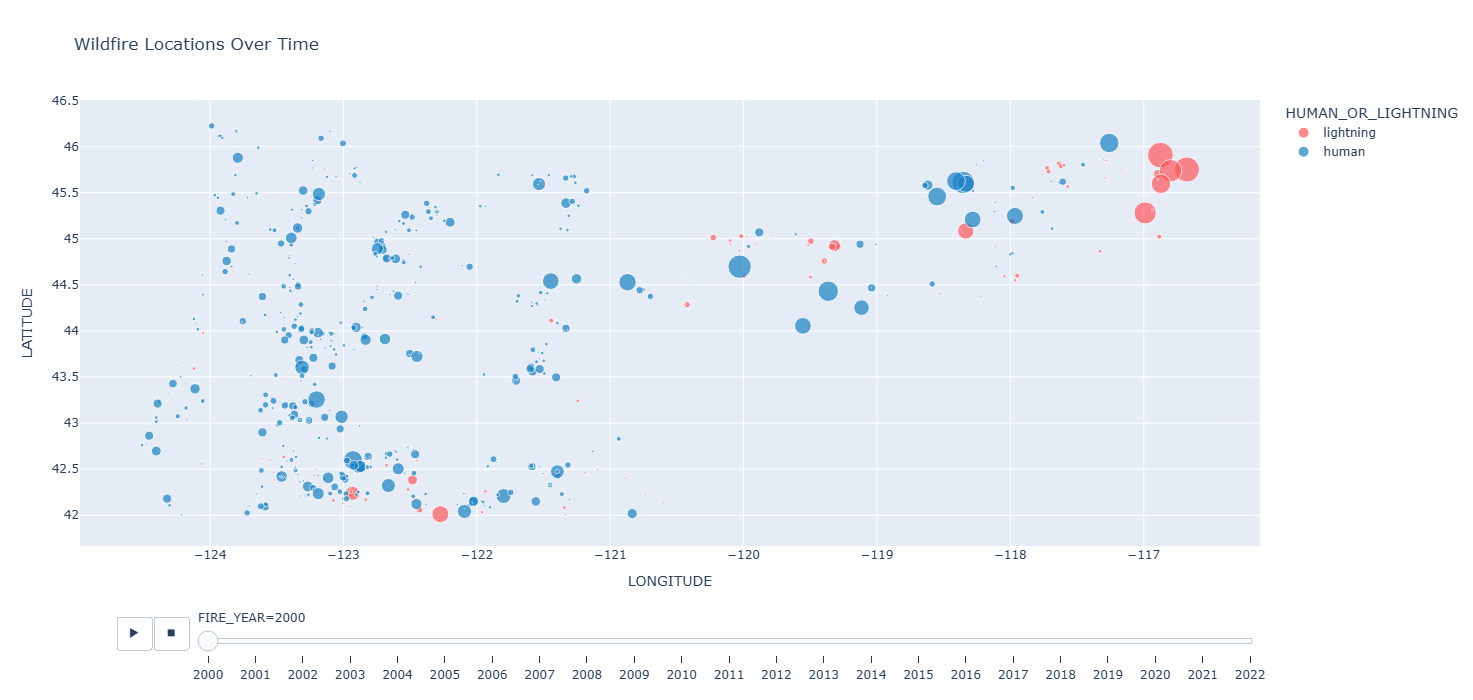

In [43]:
interactive_df = merged_df.dropna(
    subset=['EST_TOTAL_ACRES', 'LATITUDE', 'LONGITUDE', 'FIRE_YEAR']
).copy()

interactive_df['LOG_ACRES'] = np.log1p(
    interactive_df['EST_TOTAL_ACRES']
)

fig = px.scatter(
    interactive_df,
    x='LONGITUDE',
    y='LATITUDE',
    color='HUMAN_OR_LIGHTNING',
    size='LOG_ACRES',
    animation_frame='FIRE_YEAR',
    hover_name='FIRE_NAME',
    title='Wildfire Locations Over Time',
    color_discrete_sequence=['#ff595e', '#1982c4'],
    category_orders={
        'FIRE_YEAR': sorted(interactive_df['FIRE_YEAR'].unique())
    }
)

fig.update_layout(
    width=1000,
    height=700
)

fig.show()

What we can see from this graph is many of the worst non-human fires tend to be in isolated places along the Oregon borders, and that many of the worst human-caused fires happen around forested population centers or large cities.

<a id="grouped-analysis"></a>
---
## Grouped Analysis 


We decided to create an analysis based on the individual counts of fires from each year based on the original cause. This led to some interesting findings, as you'll see much better in the visualization, there seems to be a somewhat noticeable increase in the frequency of fires over the years. In particular, the number of fires caused by humans seems to have increased.

In [35]:
fire_counts = merged_df.groupby(['FIRE_YEAR', 'HUMAN_OR_LIGHTNING']).size().reset_index(name='COUNT')
fire_counts

,FIRE_YEAR,HUMAN_OR_LIGHTNING,COUNT
0,2000,human,758
1,2000,lightning,163
2,2001,human,802
3,2001,lightning,487
4,2002,human,869
5,2002,lightning,306
6,2003,human,822
7,2003,lightning,352
8,2004,human,663
9,2004,lightning,258


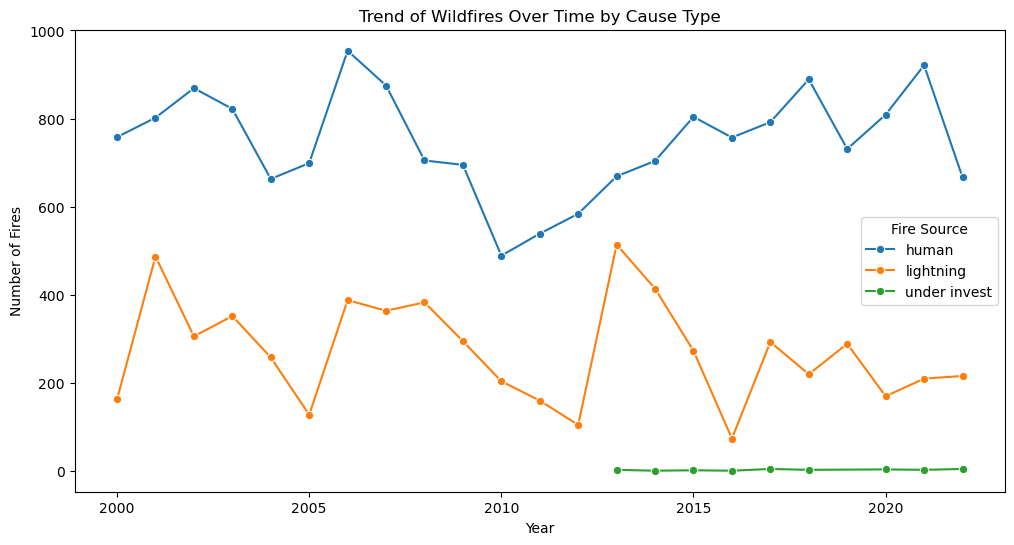

In [36]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=fire_counts,
    x='FIRE_YEAR',
    y='COUNT',
    hue='HUMAN_OR_LIGHTNING',
    marker='o'
)

plt.title('Trend of Wildfires Over Time by Cause Type')
plt.xlabel('Year')
plt.ylabel('Number of Fires')

plt.legend(title='Fire Source')

plt.show()

As described above, there is an increase in human-created fires. However, we notice waves of fires that are naturally occuring, could this be related to fire regimes or other forms of ecologcal or non-ecological interference?

# **Summary of Findings**

There was some, but not much, correlation between human activity and increasing amounts of wildfires. However, there was a clear trend in the increase of wildfire severity from both human and natural fires. In addition, our data analysis showed at least some minor correlation between geographic location and the frequency of wildfires, as well as their severity. The clear trend in the increase of wildfire severity somes from our Wildfire Size Trends Over Time faceted plot, which shows that many of the largest wildfires, with some outliers, have gotten worse and larger with time. As for location and severity, that comes from our other two visualizations, which show that many fires happen along the more forested areas of Oregon (the coast and the northeast), as well as the most severe fires, both natural and man made, tend to happen in the South, along the California border, which only has two main roads going through it, and along the remote northeast.

This leaves us with some questions, one of them being: If there is other human cause for the trend in wildfire severity (such as climate change), would it be possible to find that link in a paper or article somewhere online that corroborates our data? Again, another question that comes up is: is there a link between where wildfires are most severe and where fire stations are, or even the remoteness of these areas by road travel? And the final question that may be asked: Is there an increase in human related fires over time in Oregon, and is there data online that corroborates our grouping, which suggests that there does seem to be a trend increase? These are the questions that we may need to find answers to before we conclude our project.

## Related Articles

Based upon data from two articles, one published by Department of Agriculture, and another from ESA Journals, it would seem some of the data from our findings bear fruit. The department of Agriculture, in their article, says, "Single fires cannot be attributed to climate change unless a thorough, scientific attribution analysis of fire conditions is conducted. However, overall trends can be attributed to climate change (over 20- to 30-year time periods). Many recent trends in wildfire are consistent with climate change projections and what is expected in the future." This seems to lend credence to at least part of the findings seen earlier: That the severity and frequency of fires in Oregon has increased due to prolonged drought periods and rising temperatures.

However, the ESA Journals article introduces an intersting juxtaposition. While it does not deny that climate change will likely affect the fire regimes of Oregon, and that they are very likely also caused by human intervention in forest control, planting, and infrastructure, it suggests, "The 2020 Labor Day fires were a wake-up call to many scientists, forest managers, policy makers, and the public on the westside of Oregon and Washington. The fires were unprecedented relative to the recent fire record in terms of human impact, burn severity, and size, but were well within the bounds of historical records and natural fire regimes that shaped westside landscapes historically." This brings to mind an idea that was not considered in our original question: could this still be natural, despite human intervention?

# Conclusion

The data from our two datasets seems to corroborate, at least in part, the original research question. In fact, even some outside phenomenon, not really displayed in the data, seem to be at play here, such as climate change and human forest managing, corroborated by the articles researched for this project. However, even then, they cast some doubt on it being historically unprecedented or even outrageously large increases in fires or their severity, as the ESA article claims. 

Due to this inquiry which one of the articles brought to head, there is ultimately, only one path that should be taken, if this project were to move forward: more research. Though it would likely be better if it encompassed more states than simply Oregon, and perhaps, more fire data than what was provided by our primary and secondary datasets, It is clear that more research into other topics, such as global warming, fire regimes, as well as forest management that must be taken in to consideration before pursuing this question further. Yes, the data does paint some correlation between humans and more fires, but some of these fires could also well and likely be fires in the city, not necessarily a forest or other wild area. 

To conclude this project, the answer to the original question is this: humans have likely contributed to the increase in forest fires, but, that more data should be gathered, and that that data is not available in these datasets, but could be compared with it.

## Works Cited

[Tatman, Rachael. 1.88 Million US Wildfires. Kaggle, https://www.kaggle.com/datasets/rtatman/188-million-us-wildfires
. Accessed 11 May 2026.](https://www.kaggle.com/datasets/rtatman/188-million-us-wildfires?resource=download)
                          
[Oregon Department of Forestry. ODF Fire Occurrence Data (2000–2022). Oregon Open Data Portal, https://data.oregon.gov/Natural-Resources/ODF-Fire-Occurrence-Data-2000-2022/fbwv-q84y
, Accessed 11 May 2026.](https://data.oregon.gov/Natural-Resources/ODF-Fire-Occurrence-Data-2000-2022/fbwv-q84y/related_content)

[“Climate Change and Wildfire in Idaho, Oregon, and Washington.” USDA Climate Hubs, United States Department of Agriculture, https://www.climatehubs.usda.gov/hubs/northwest/topic/climate-change-and-wildfire-idaho-oregon-and-washington
. Accessed 11 May 2026.](https://www.climatehubs.usda.gov/hubs/northwest/topic/climate-change-and-wildfire-idaho-oregon-and-washington)

[Reilly, Matthew J., et al. “Cascadia Burning: The Historic, but Not Historically Unprecedented, 2020 Wildfires in the Pacific Northwest, USA.” Ecosphere, vol. 13, no. 6, 2022, p. e4070, Wiley Online Library, https://doi.org/10.1002/ecs2.4070
.](https://esajournals.onlinelibrary.wiley.com/doi/10.1002/ecs2.4070)